# Batch Jump-Height Calculation (per rep)

Each recording holds ~3 countermovement jumps plus rest. This notebook:

1. parses the dash-delimited MediaPipe stream into named columns,
2. **segments each file into individual reps** with `get_reps` (the step the
   original `calculate_jump` was missing - `mm_per_px` and `ts_jump_height`
   are designed to run on one rep, see `PTM.gravity()`),
3. computes a height **per rep** two ways:
   - **gravity** - your `PTM.mm_per_px` scaling x toe displacement,
   - **flight-time** - `g*t^2/8`, scale-free, using `get_flight_time`.

**Heads-up on units / coordinates:** `ts_jump_height` divides by 10, so its
output is **cm**. And `mm_per_px` / `get_flight_time` were tuned for OpenPose
**pixel** coordinates; their internal `rest/max` heuristic behaves differently
on MediaPipe's normalized [0,1] values, so the flight-time `rel_height` is
exposed below as a knob you calibrate with the plot in the last section.

Run Jupyter from your project root so `utilities` imports resolve.


## 1. Imports

In [1]:
import glob
import os

import numpy as np
import pandas as pd
from scipy.constants import g
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

from utilities.utils import flip_axis, ts_jump_height, get_reps, get_flight_time, height_with_peak
import utilities.PTM as PTM

%matplotlib inline

## 2. Configuration

In [2]:
DATA_DIR      = "keypoints/cmj"   # folder containing your text files
PATTERN       = "*.txt"        # file glob
FPS           = 30             # frame rate
SKIP_WORLD    = True           # skip *_world.txt (world landmarks unusable here)

# Segmentation
D_SEC         = 5              # min seconds between rep peaks (matches PTM.gravity)
EXPECTED_REPS = 3              # jumps per file

# Flight-time method: where on the peak to measure flight width (0..1).
# ~0.85-0.95 measures near the take-off/landing base. Calibrate in section 7.
REL_HEIGHT    = 0.9

files = sorted(glob.glob(os.path.join(DATA_DIR, PATTERN)))
if SKIP_WORLD:
    files = [f for f in files if "world" not in os.path.basename(f).lower()]
print(f"Using {len(files)} file(s):")
for f in files:
    print("  ", os.path.basename(f))

Using 32 file(s):
   P03_CMJBL_FRONT.txt
   P03_CMJUL_FRONT.txt
   P04_CMJ_BL_FRONT.txt
   P04_CMJ_UL_FRONT.txt
   P05_CMJ_BL_FRONT.txt
   P05_CMJ_UL_FRONT.txt
   P06_CMJ_BL_FRONT.txt
   P06_CMJ_UL_FRONT.txt
   P07_CMJ_BL_FRONT.txt
   P07_CMJ_UL_FRONT.txt
   P08_CMJ_BL_FRONT.txt
   P08_CMJ_UL_FRONT.txt
   P09_CMJ_BL_FRONT.txt
   P09_CMJ_UL_FRONT.txt
   P10_CMJ_BL_FRONT.txt
   P10_CMJ_UL_FRONT.txt
   P11_CMJ_BL_FRONT.txt
   P11_CMJ_UL_FRONT.txt
   P12_CMJ_BL_FRONT.txt
   P12_CMJ_UL_FRONT.txt
   P13_CMJ_BL_FRONT.txt
   P13_CMJ_UL_FRONT.txt
   P14_CMJ_BL_FRONT.txt
   P14_CMJ_UL_FRONT.txt
   P15_CMJ_BL_FRONT.txt
   P15_CMJ_UL_FRONT.txt
   P16_CMJ_BL_FRONT.txt
   P16_CMJ_UL_FRONT.txt
   P17_CMJ_BL_FRONT.txt
   P17_CMJ_UL_FRONT.txt
   P18_CMJ_BL_FRONT.txt
   P18_CMJ_UL_FRONT.txt


## 3. Loader - dash-delimited frame stream -> named columns

Each frame is 99 numbers (`x,y,z` for 33 BlazePose landmarks); frames are
separated by a lone `-` (the file ends with one). Real negatives like `-0.36`
keep their digits - only a standalone `-` is a separator. Every frame is
checked for exactly 99 values so a truncated frame is caught, not silently
shifted.

In [3]:
POSE_LANDMARKS = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR", "RIGHT_EAR",
    "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER", "RIGHT_SHOULDER",
    "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST", "RIGHT_WRIST",
    "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX", "RIGHT_INDEX",
    "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
COORDS = ("x", "y", "z")
PER_FRAME = len(POSE_LANDMARKS) * len(COORDS)   # 99


def load_pose_file(path):
    raw = open(path).read().replace(",", " ")
    frames, cur = [], []
    for tok in raw.split():
        if tok == "-":
            if cur:
                frames.append(cur); cur = []
        else:
            cur.append(float(tok))
    if cur:
        frames.append(cur)

    bad = [(i, len(f)) for i, f in enumerate(frames) if len(f) != PER_FRAME]
    if bad:
        raise ValueError(f"{len(bad)} frame(s) not {PER_FRAME} long: {bad[:5]}")

    arr = np.array(frames).reshape(len(frames), len(POSE_LANDMARKS), len(COORDS))
    cols = {f"{n}_{c}": arr[:, i, j]
            for i, n in enumerate(POSE_LANDMARKS) for j, c in enumerate(COORDS)}
    return pd.DataFrame(cols)


if files:
    df = load_pose_file(files[0])
    print(os.path.basename(files[0]), "->", df.shape, "(frames, columns)")

P03_CMJBL_FRONT.txt -> (1122, 99) (frames, columns)


## 4. Per-rep calculation

`get_reps` segments the flipped, smoothed hip trace into jumps; for each rep we
slice the matching toe window and compute both heights.

In [4]:
def calculate_jumps(data, fps=FPS, d_sec=D_SEC, expected_reps=EXPECTED_REPS,
                    rel_height=REL_HEIGHT):
    hip = np.column_stack([(data["LEFT_HIP_x"] + data["RIGHT_HIP_x"]) / 2,
                           (data["LEFT_HIP_y"] + data["RIGHT_HIP_y"]) / 2])
    toe = data[["RIGHT_FOOT_INDEX_x", "RIGHT_FOOT_INDEX_y"]].to_numpy()

    hip_y = savgol_filter(flip_axis(hip.copy())[:, 1], 11, 2)   # up = positive
    toe_y = flip_axis(toe.copy())[:, 1]

    segs, reps = get_reps(hip_y, fps=fps, d=d_sec, expected_reps=expected_reps)

    rows = []
    for i, (seg, rep) in enumerate(zip(segs, reps)):
        s, e = int(seg[0]), int(seg[1])
        row = {"rep": i + 1, "rep_frames": len(rep)}

        # Method A - gravity-scaled toe displacement (your PTM method)
        try:
            mm_px = PTM.mm_per_px(rep, fps=fps)
            row["grav_cm"] = ts_jump_height(toe_y[s:e] * mm_px, fps=fps)
            row["mm_px"] = round(float(mm_px), 2)
        except Exception as ex:
            row["grav_cm"], row["mm_px"] = np.nan, np.nan
            row["grav_err"] = str(ex)[:60]

        # Method B - flight time, scale-free (rel_height is the tunable knob)
        try:
            ft, _ = get_flight_time(rep, fps, d=5, rel_height=rel_height)
            t = float(ft[0])
            row["flight_s"] = round(t, 3)
            row["ft_cm"] = round((g / 8) * t ** 2 * 100, 1)
        except Exception as ex:
            row["flight_s"], row["ft_cm"] = np.nan, np.nan
            row["ft_err"] = str(ex)[:60]

        rows.append(row)
    return rows

## 5. Run over every file (one row per rep)

In [5]:
records = []

for path in files:
    name = os.path.basename(path)
    try:
        data = load_pose_file(path)
        rep_rows = calculate_jumps(data)
        if not rep_rows:
            records.append({"file": name, "rep": np.nan, "error": "no reps found"})
        for r in rep_rows:
            records.append({"file": name, **r})
        print(f"OK   {name:34s}  {len(rep_rows)} rep(s)")
    except Exception as e:
        records.append({"file": name, "rep": np.nan, "error": str(e)})
        print(f"FAIL {name:34s}  {e}")

df_reps = pd.DataFrame(records)
print(f"\n{len(df_reps)} rep-rows from {df_reps['file'].nunique()} file(s).")

OK   P03_CMJBL_FRONT.txt                 3 rep(s)
OK   P03_CMJUL_FRONT.txt                 3 rep(s)
OK   P04_CMJ_BL_FRONT.txt                3 rep(s)
OK   P04_CMJ_UL_FRONT.txt                3 rep(s)
OK   P05_CMJ_BL_FRONT.txt                3 rep(s)
OK   P05_CMJ_UL_FRONT.txt                3 rep(s)
OK   P06_CMJ_BL_FRONT.txt                3 rep(s)
OK   P06_CMJ_UL_FRONT.txt                3 rep(s)
OK   P07_CMJ_BL_FRONT.txt                3 rep(s)
OK   P07_CMJ_UL_FRONT.txt                3 rep(s)
OK   P08_CMJ_BL_FRONT.txt                3 rep(s)
OK   P08_CMJ_UL_FRONT.txt                3 rep(s)
OK   P09_CMJ_BL_FRONT.txt                3 rep(s)
OK   P09_CMJ_UL_FRONT.txt                3 rep(s)
OK   P10_CMJ_BL_FRONT.txt                3 rep(s)
OK   P10_CMJ_UL_FRONT.txt                3 rep(s)
OK   P11_CMJ_BL_FRONT.txt                3 rep(s)
OK   P11_CMJ_UL_FRONT.txt                4 rep(s)
OK   P12_CMJ_BL_FRONT.txt                3 rep(s)
OK   P12_CMJ_UL_FRONT.txt                3 rep(s)


## 6. Results

In [6]:
df_reps

,file,rep,rep_frames,grav_cm,mm_px,flight_s,ft_cm
0,P03_CMJBL_FRONT.txt,1,75,23.35,4577.18,0.592,43.0
1,P03_CMJBL_FRONT.txt,2,75,25.75,4902.27,0.570,39.9
2,P03_CMJBL_FRONT.txt,3,75,26.21,5129.29,0.604,44.8
3,P03_CMJUL_FRONT.txt,1,75,13.31,4082.73,0.544,36.3
4,P03_CMJUL_FRONT.txt,2,75,13.03,4326.96,0.536,35.3
...,...,...,...,...,...,...,...
93,P18_CMJ_BL_FRONT.txt,2,75,24.91,5393.65,0.657,52.8
94,P18_CMJ_BL_FRONT.txt,3,75,32.38,6095.41,0.655,52.6
95,P18_CMJ_UL_FRONT.txt,1,75,10.16,7232.89,0.521,33.3
96,P18_CMJ_UL_FRONT.txt,2,75,13.56,6847.28,0.570,39.8


### Per-file summary (best rep)

Common CMJ practice is best-of-3. Adjust `.max()` to `.mean()` if you prefer.

In [7]:
summary = (df_reps.groupby("file")[["grav_cm", "ft_cm"]]
           .max().reset_index().rename(columns={"grav_cm": "best_grav_cm",
                                                 "ft_cm": "best_ft_cm"}))
summary

,file,best_grav_cm,best_ft_cm
0,P03_CMJBL_FRONT.txt,26.21,44.8
1,P03_CMJUL_FRONT.txt,14.19,42.9
2,P04_CMJ_BL_FRONT.txt,10.79,48.0
3,P04_CMJ_UL_FRONT.txt,16.14,37.1
4,P05_CMJ_BL_FRONT.txt,22.59,36.0
5,P05_CMJ_UL_FRONT.txt,11.72,38.8
6,P06_CMJ_BL_FRONT.txt,26.69,34.5
7,P06_CMJ_UL_FRONT.txt,17.38,29.5
8,P07_CMJ_BL_FRONT.txt,17.55,38.8
9,P07_CMJ_UL_FRONT.txt,24.64,35.0


In [8]:
df_reps.to_csv("jump_heights_per_rep.csv", index=False)
summary.to_csv("jump_heights_summary.csv", index=False)
print("Saved -> jump_heights_per_rep.csv, jump_heights_summary.csv")

Saved -> jump_heights_per_rep.csv, jump_heights_summary.csv


## 7. Calibrate on one file (do this before trusting the numbers)

Plots the segmentation and, for the first rep, the flight width that
`get_flight_time` measures at the current `REL_HEIGHT`. The red line should
span the airborne phase (toes off the ground). If it's too narrow, raise
`REL_HEIGHT` toward 1.0; if it grabs the countermovement too, lower it. Re-run
section 5 once it looks right.

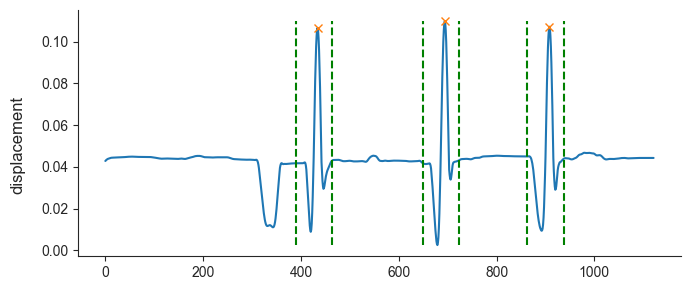

P03_CMJBL_FRONT.txt: 3 rep(s)


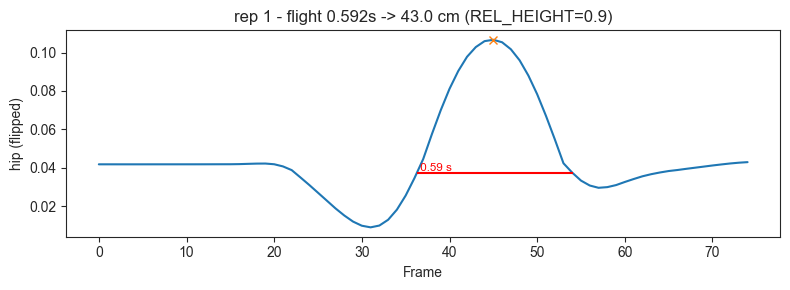

In [9]:
dbg = files[0]
data = load_pose_file(dbg)
hip = np.column_stack([(data["LEFT_HIP_x"] + data["RIGHT_HIP_x"]) / 2,
                       (data["LEFT_HIP_y"] + data["RIGHT_HIP_y"]) / 2])
hip_y = savgol_filter(flip_axis(hip.copy())[:, 1], 11, 2)

# show segmentation
segs, reps = get_reps(hip_y, fps=FPS, d=D_SEC, expected_reps=EXPECTED_REPS,
                      plot_peaks=True)
print(f"{os.path.basename(dbg)}: {len(reps)} rep(s)")

# show flight width on the first rep at current REL_HEIGHT
fig, ax = plt.subplots(figsize=(8, 3), dpi=100)
jt, jh, _ = height_with_peak(reps[0], FPS, d=5, rel_height=REL_HEIGHT,
                             ax=ax, part="hip", device="MediaPipe")
ax.set_title(f"rep 1 - flight {np.round(jt[0],3)}s -> {np.round(jh[0]*100,1)} cm "
             f"(REL_HEIGHT={REL_HEIGHT})")
ax.set_xlabel("Frame"); ax.set_ylabel("hip (flipped)")
plt.tight_layout(); plt.show()